In [1]:
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.oscprobstd as oscprobstd
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

# 0. Helper functions and definitions

In [2]:
col_full = '#E76F51'
col_ang = '#2A9D8F'
col_en = '#E9C46A'
col_count = '#73A8BF'#'#2A9D8F'


In [3]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

# 1. Probabilities 2$\nu$: in vacuum

## 1.1 General definitions

In [4]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

## 1.2 Probabilities vs. distance

### Generate probabilities

In [5]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# Both probabilities are computed for the *whole* array of baselines in a single
# call. Do not replace this with a loop over `distances` that calls osc_prob once
# per point: on this machine that costs ~4.5 ms per call against ~0.17 ms per
# point here, so this cell would take about 45 s instead of about 2 s.
#
# The reason is that the ~4.5 ms is almost entirely fixed entry-path cost --
# argument unpacking, input validation, Hamiltonian probing, strategy dispatch --
# paid once per call no matter how little integration follows. Passing an array
# pays it once for all 10000 points. (n_slabs=1 and n_slabs=150 both measure
# 4.5 ms per call, which is how you can tell the physics is not what costs.)

# Using the standard formula
prob_std = oscprobstd.osc_prob_2nu_vacuum_std(
    sth, Dm2, energy, distances*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion
prob = oscprob.osc_prob_2nu_vacuum(
    energy, distances*gd.CONV_KM_TO_INV_EV, sth, Dm2, nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

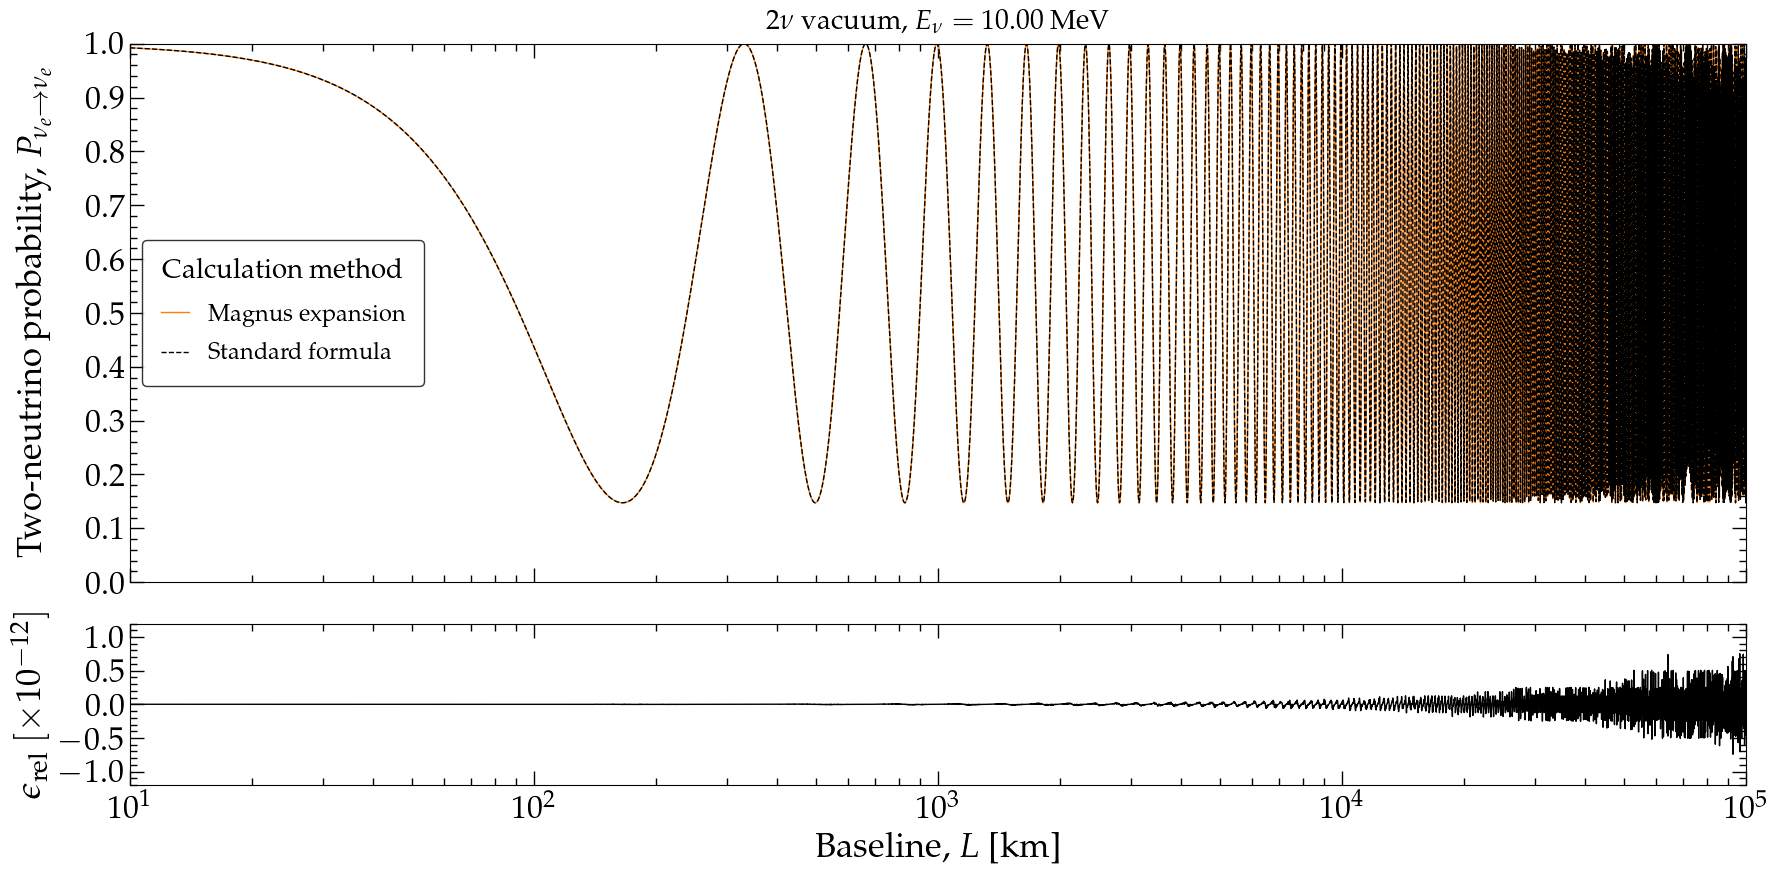

In [6]:
fig, ax = plotting.plot_probability_vs_baseline(
    distances,
    [dict(y=prob, label='Magnus expansion', color='C1'),
     dict(y=prob_std, label='Standard formula', color='k', ls='--')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2,
    xlim=(l_ini, l_fin),
    residual=(prob-prob_std)/prob_std/1.e-12,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ylim=(-1.2, 1.2), residual_ymajor=0.50, residual_yminor=0.10,
    legend_title=r'Calculation method', legend_loc='center left',
    title=r'$2\nu$~vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    savefig='../fig/prob_2nu_vacuum_vs_baseline.pdf')

## 1.3 Probabilities vs. energy

### Generate probabilities

In [7]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]

# Both probabilities are computed for the *whole* array of baselines in a single
# call. Do not replace this with a loop over `distances` that calls osc_prob once
# per point: on this machine that costs ~4.5 ms per call against ~0.17 ms per
# point here, so this cell would take about 23 s instead of about 1 s.
#
# The reason is that the ~4.5 ms is almost entirely fixed entry-path cost --
# argument unpacking, input validation, Hamiltonian probing, strategy dispatch --
# paid once per call no matter how little integration follows. Passing an array
# pays it once for all 5000 points. (n_slabs=1 and n_slabs=150 both measure
# 4.5 ms per call, which is how you can tell the physics is not what costs.)
# The energy axis batches the same way the baseline axis does.

# Using the standard formula
prob_std = oscprobstd.osc_prob_2nu_vacuum_std(
    sth, Dm2, energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion
prob = oscprob.osc_prob_2nu_vacuum(
    energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV, sth, Dm2,
    nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

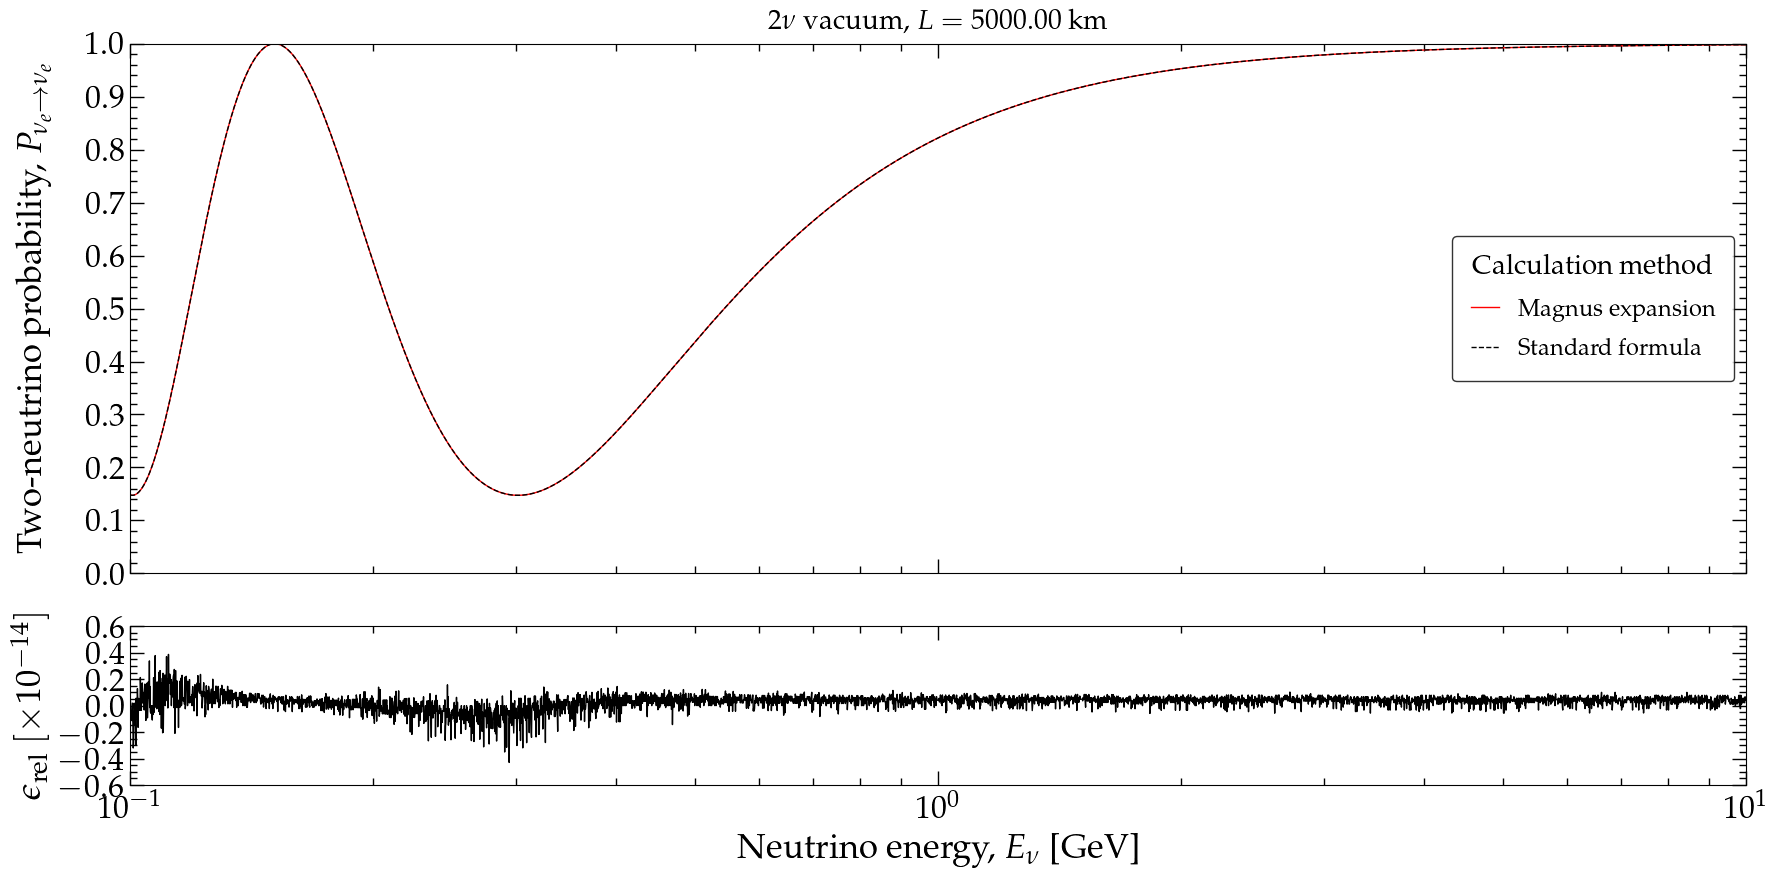

In [8]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob, label='Magnus expansion', color='r'),
     dict(y=prob_std, label='Standard formula', color='k', ls='--')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2,
    xlim=(energy_min, energy_max),
    residual=(prob-prob_std)/prob_std/1.e-14,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-14}]$',
    residual_ylim=(-0.6, 0.6), residual_ymajor=0.20, residual_yminor=0.05,
    legend_title=r'Calculation method', legend_loc='center right',
    title=r'$2\nu$~vacuum, $L = $~{:.2f}~km'.format(baseline),
    savefig='../fig/prob_2nu_vacuum_vs_energy.pdf')

# 2. Probabilities 2$\nu$: in matter with constant density

## 2.1 General definitions

In [9]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

## 2.2 Probabilities vs. distance

### Generate probabilities

In [10]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
# The potential is still built by hand here, because the standard formula below
# needs it explicitly. Note density_matter_is_in_g_per_cm3=True: without it, rho
# is taken to be in internal units already and the potential comes out ~4e18
# times too small, which looks exactly like having no matter at all.
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho,
                                          electron_fraction=0.5,
                                          density_matter_is_in_g_per_cm3=True) # [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # [eV]

# Both probabilities are computed for the *whole* array of baselines in a single
# call. Do not replace this with a loop over `distances` that calls osc_prob once
# per point: on this machine that costs ~4.5 ms per call against ~0.17 ms per
# point here, so this cell would take about 2 min instead of about 5 s.
#
# The reason is that the ~4.5 ms is almost entirely fixed entry-path cost --
# argument unpacking, input validation, Hamiltonian probing, strategy dispatch --
# paid once per call no matter how little integration follows. Passing an array
# pays it once for all 10000 points. (n_slabs=1 and n_slabs=150 both measure
# 4.5 ms per call, which is how you can tell the physics is not what costs.)

# Using the standard formula
prob_matt_std = oscprobstd.osc_prob_2nu_matter_std(
    sth, Dm2, VCC, energy, distances*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion. The wrapper takes the density directly and builds
# the potential itself, so the matter Hamiltonian never has to be assembled by
# hand -- and its sign cannot be got wrong.
prob_matt = oscprob.osc_prob_2nu_matter_constant_density(
    energy, distances*gd.CONV_KM_TO_INV_EV, rho, sth, Dm2,
    density_matter_is_in_g_per_cm3=True, nu_i=nu_i, nu_f=nu_f)

# In vacuum, for comparison
prob_vac = oscprob.osc_prob_2nu_vacuum(
    energy, distances*gd.CONV_KM_TO_INV_EV, sth, Dm2, nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

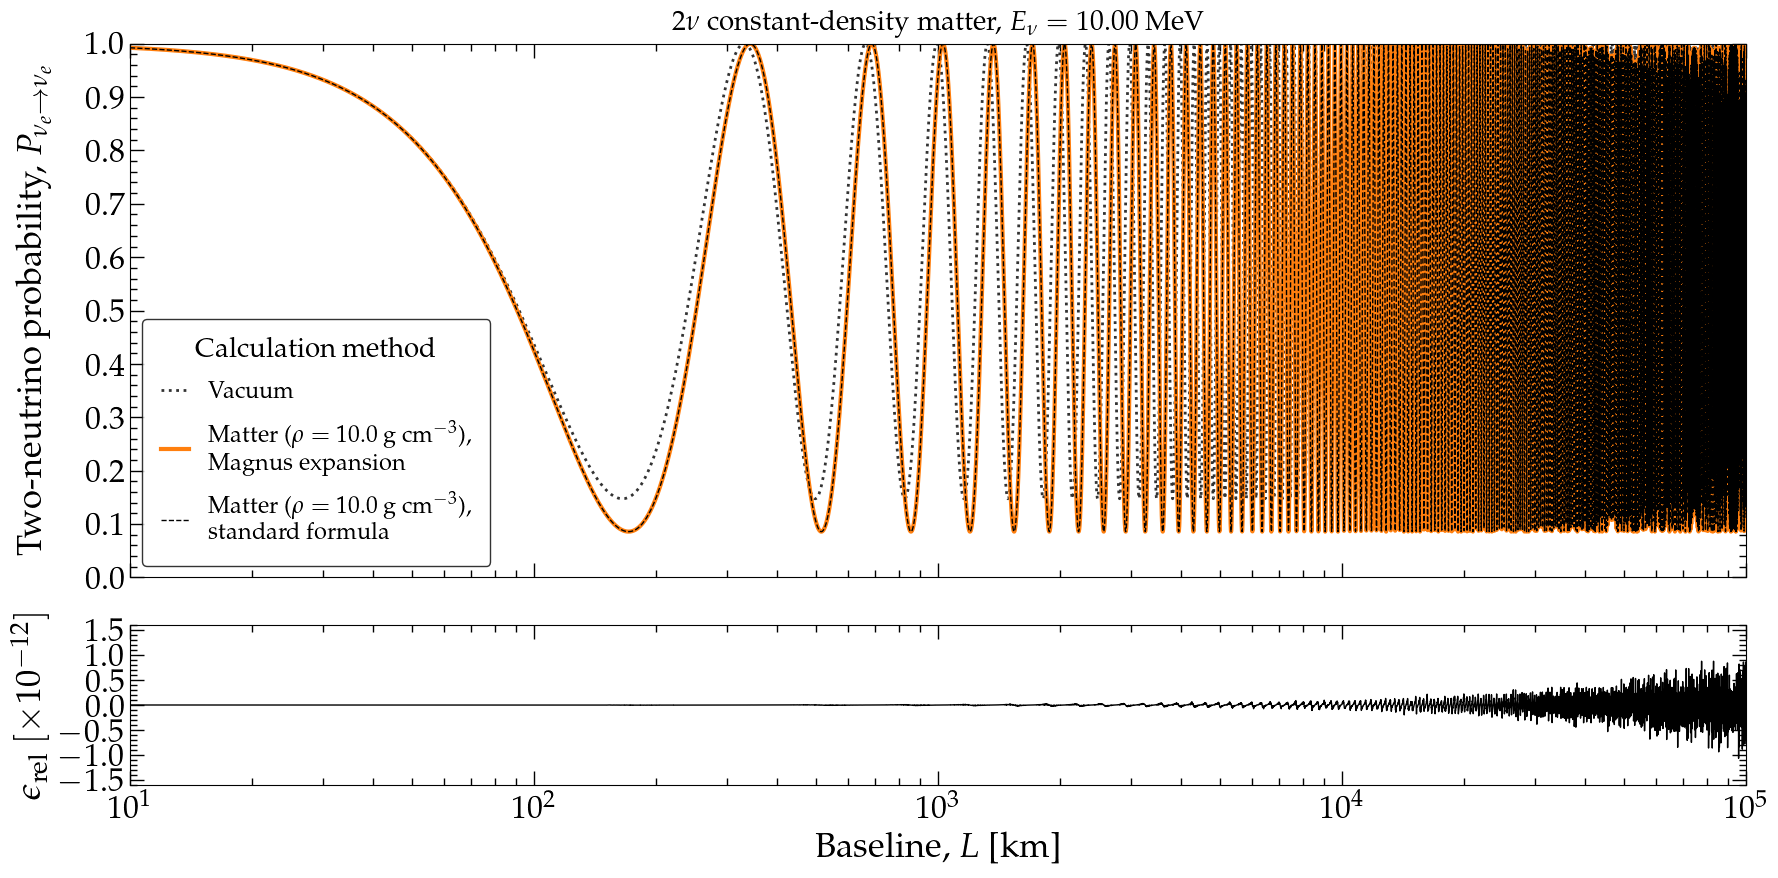

In [11]:
fig, ax = plotting.plot_probability_vs_baseline(
    distances,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', ls=':', lw=2),
     dict(y=prob_matt, color='C1', lw=3,
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'Magnus expansion'),
     dict(y=prob_matt_std, color='k', ls='--',
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'standard formula')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2,
    xlim=(l_ini, l_fin),
    residual=(prob_matt-prob_matt_std)/prob_matt_std/1.e-12,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ylim=(-1.6, 1.6), residual_ymajor=0.50, residual_yminor=0.10,
    legend_title=r'Calculation method', legend_loc='lower left',
    title=r'$2\nu$~constant-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    savefig='../fig/prob_2nu_matter_vs_baseline.pdf')

## 2.3 Probabilities vs. energy

### Generate probabilities

In [12]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho,
                                          electron_fraction=0.5,
                                          density_matter_is_in_g_per_cm3=True) # [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # [eV]

# Both probabilities are computed for the *whole* array of baselines in a single
# call. Do not replace this with a loop over `distances` that calls osc_prob once
# per point: on this machine that costs ~4.5 ms per call against ~0.17 ms per
# point here, so this cell would take about 1 min instead of about 3 s.
#
# The reason is that the ~4.5 ms is almost entirely fixed entry-path cost --
# argument unpacking, input validation, Hamiltonian probing, strategy dispatch --
# paid once per call no matter how little integration follows. Passing an array
# pays it once for all 5000 points. (n_slabs=1 and n_slabs=150 both measure
# 4.5 ms per call, which is how you can tell the physics is not what costs.)

# Using the standard formula
prob_matt_std = oscprobstd.osc_prob_2nu_matter_std(
    sth, Dm2, VCC, energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion
prob_matt = oscprob.osc_prob_2nu_matter_constant_density(
    energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV, rho, sth, Dm2,
    density_matter_is_in_g_per_cm3=True, nu_i=nu_i, nu_f=nu_f)

# In vacuum, for comparison
prob_vac = oscprob.osc_prob_2nu_vacuum(
    energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV, sth, Dm2,
    nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

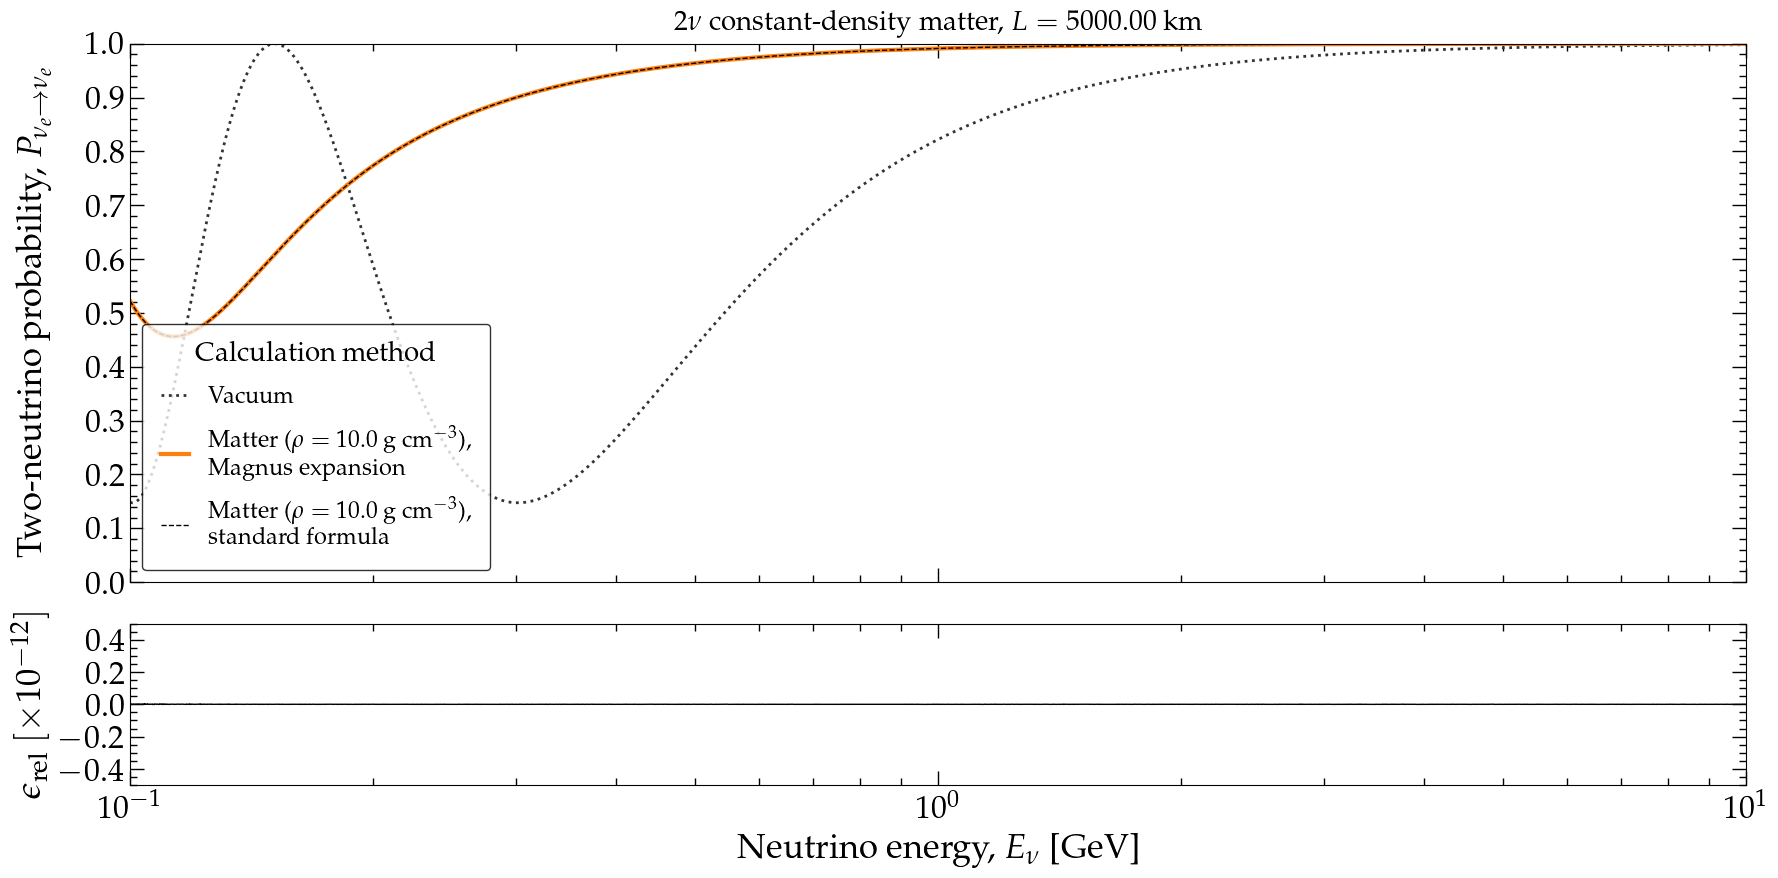

In [13]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', ls=':', lw=2),
     dict(y=prob_matt, color='C1', lw=3,
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'Magnus expansion'),
     dict(y=prob_matt_std, color='k', ls='--',
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'standard formula')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2, energy_unit='GeV',
    xlim=(energy_min, energy_max),
    residual=(prob_matt-prob_matt_std)/prob_matt_std/1.e-12,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ylim=(-0.5, 0.5), residual_ymajor=0.20, residual_yminor=0.05,
    legend_title=r'Calculation method', legend_loc='lower left',
    title=r'$2\nu$~constant-density matter, $L = $~{:.2f}~km'.format(baseline),
    savefig='../fig/prob_2nu_matter_vs_energy.pdf')

# 3. Probabilities 2$\nu$: in matter with varying density

## 3.1 General definitions

In [14]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [15]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale = 100.0 # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper.
# [l] = km
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_center) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, exponentially falling density
# --------------------------------------------------------------
# [l] = km
def num_density_e_exp_func(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale) # [eV^3]
def VCC_func_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp_func(r, num_density_e_center, l_scale)) # [eV]
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density(l, num_density_e_center, l_scale))


# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
# [l] = km
num_density_e_basal = 0*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_central = 8*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_central, l_width = 300.0, 100.0 # [km]
def num_density_e_gaussian_func(l, num_density_e_central, l_central, l_width):
    return num_density_e_basal+num_density_e_central*np.exp( -(l/gd.CONV_KM_TO_INV_EV-l_central)**2/(2.0*l_width**2)) # [eV^3]
def VCC_func_gaussian_density(l, num_density_e_central, l_central, l_width):
    return matter.VCC_func(l, lambda r: num_density_e_gaussian_func(r, num_density_e_central, l_central, l_width)) # [eV]
def H_func_gaussian_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_gaussian_density(l, 
                                                    num_density_e_central, l_central, l_width)) # [eV]

## 3.2 Probabilities vs. distance

### Generate probabilities

In [16]:
# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, exponentially falling density
# --------------------------------------------------------------
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, energy), 
                                                   0, l*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
prob_matt_gaussian_density = np.array([oscprob.osc_prob(lambda l: H_func_gaussian_density(l, energy), 
                                                        0, l*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=10, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
H_vac = (1./energy)*H_vac_energy_indep # Can also call hamiltonians.hamiltonian_2nu_vacuum instead
prob_vac = np.array([oscprob.osc_prob(lambda l: H_vac,
                                      0.0, l*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

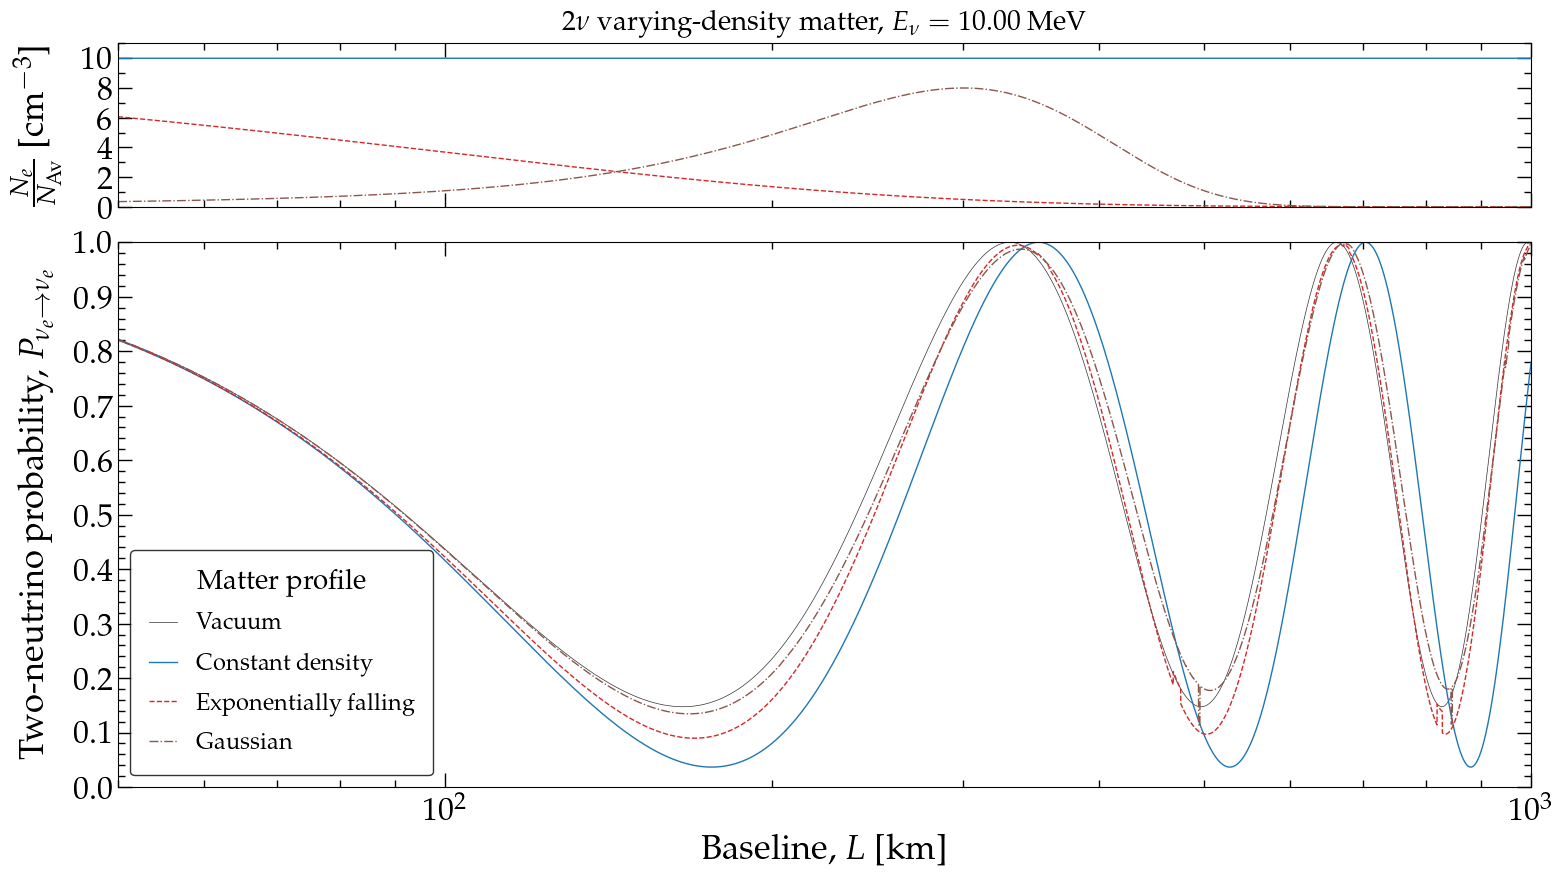

In [17]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center/norm for l in distances], color='C0'),
     dict(y=[num_density_e_exp_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center, l_scale)/norm
             for l in distances], color='C3', ls='--'),
     dict(y=[num_density_e_gaussian_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_central,
                                         l_central, l_width)/norm
             for l in distances], color='C5', ls='-.')],
    [[dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
      dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
      dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
      dict(y=prob_matt_gaussian_density, label=r'Gaussian', color='C5', ls='-.')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 11),
    profile_ymajor=2, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$2\nu$~varying-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    title_fontsize=20, ylabel_labelpad=15,
    legend_title=r'Matter profile', legend_loc='lower left', grid=False)

## 3.3 Probabilities vs. energy

### Generate probabilities

In [18]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e3 # [km]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, exponeitally falling density
# --------------------------------------------------------------
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=20, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
prob_matt_gaussian_density = np.array([oscprob.osc_prob(lambda l: H_func_gaussian_density(l, enu*gd.UNIT_MEV), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=20, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

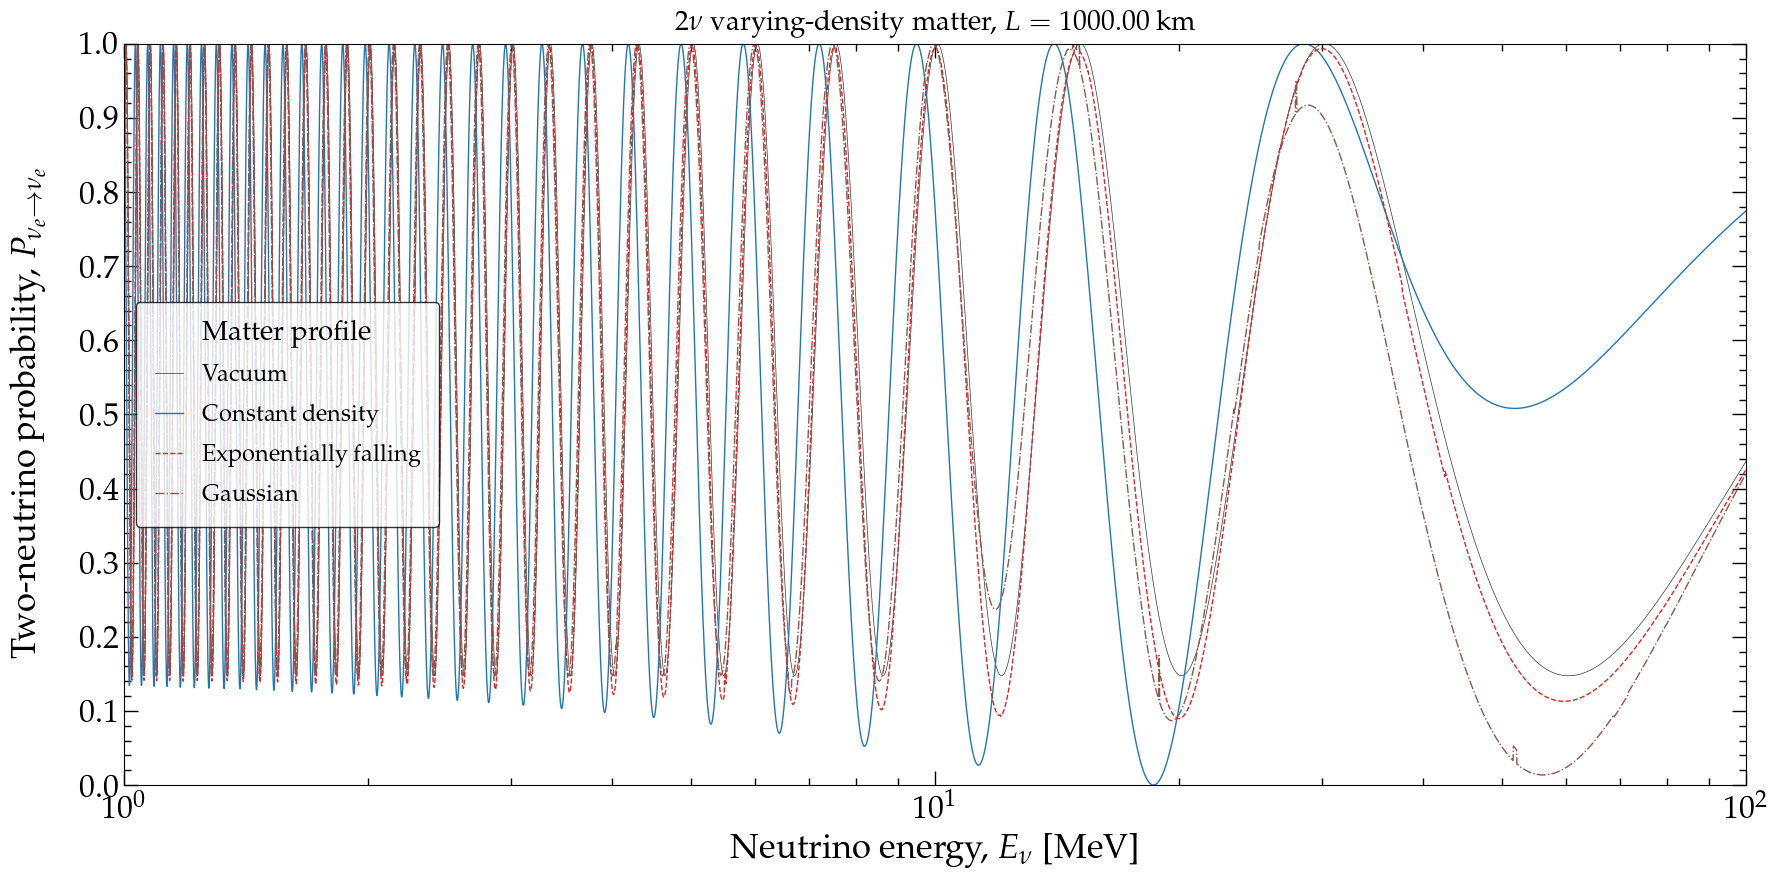

In [19]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
     dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
     dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
     dict(y=prob_matt_gaussian_density, label=r'Gaussian', color='C5', ls='-.')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2, energy_unit='MeV',
    xlim=(energy_min, energy_max),
    legend_title=r'Matter profile', legend_loc='center left',
    title=r'$2\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline))

# 4. Probabilities 2$\nu$: in matter with castle-wall density profile

## 4.1 General definitions

In [20]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [21]:
# Low and high densities of the castle-wall density profile
num_density_e_low = 1*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_high = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_avg = (num_density_e_high-num_density_e_low)/2.0 # [eV^3]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]
    
# --------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper ([l] = km)
VCC_avg = matter.VCC_func(0.0, lambda l: num_density_e_avg) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_avg) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, castle-wall density profile
# --------------------------------------------------------------
# [l] = km
def num_density_e_castle_wall_func(l, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    # np.where, not an if/else: the engine evaluates this for a whole array of
    # positions at once, and a Python `if` on an array raises "truth value of an
    # array is ambiguous". Written this way the profile stays array-capable and
    # osc_prob keeps its fast path -- see the note in notebook 01. It still
    # returns a plain number when handed a single position.
    l_scaled = (np.asarray(l)/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
    dl = 1.0/n_castle_slabs # Width of one slab
    index_slab = l_scaled // dl
    # The first slab has low density, the second one has high density, and so on
    return np.where(index_slab % 2 == 0, num_density_e_low, num_density_e_high)
def VCC_func_castle_wall(l, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    return matter.VCC_func(l, lambda r: num_density_e_castle_wall_func(r, num_density_e_low, num_density_e_high, 
                                                                       n_castle_slabs, l_ini, l_fin)) # [eV]
def H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_castle_wall(l, 
                                                                                        num_density_e_low, num_density_e_high,
                                                                                        n_castle_slabs, l_ini, l_fin))

n_castle_slabs_narrow = 50 # Narrow castle wall
n_castle_slabs_wide = 10   # Wide castle wall

## 4.2 Probabilities vs. distance

### Generate probabilities

In [22]:
# Baselines
l_ini, l_fin = 1.e2, 1.e4 #1.e2, 1.e5 # [km]
l_npts = 6000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 50.*gd.UNIT_MEV # [eV] #10

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, narrow castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_narrow = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_narrow, l_ini, l_fin), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_castle_wall_wide = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high,
                                                                                     n_castle_slabs_wide, l_ini, l_fin), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

### Plot probabilities

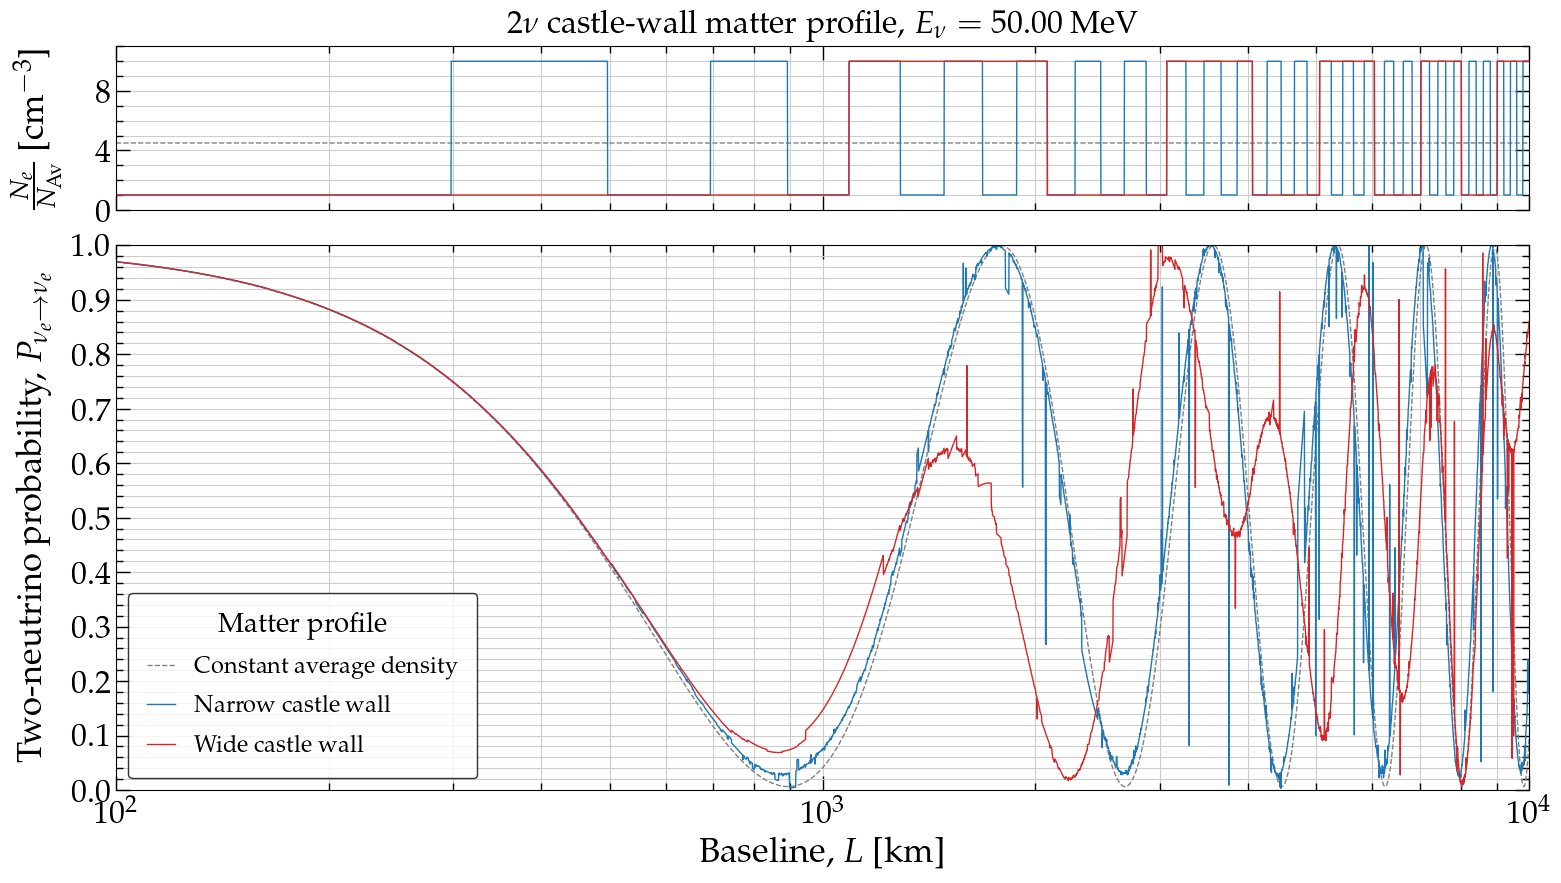

In [23]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_avg/norm for l in distances], color='0.5', ls='--'),
     dict(y=[num_density_e_castle_wall_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_low,
                                            num_density_e_high, n_castle_slabs_narrow, l_ini, l_fin)/norm
             for l in distances], color='C0'),
     dict(y=[num_density_e_castle_wall_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_low,
                                            num_density_e_high, n_castle_slabs_wide, l_ini, l_fin)/norm
             for l in distances], color='C3')],
    [[dict(y=prob_matt_const_density, label=r'Constant average density', color='0.5', ls='--'),
      dict(y=prob_matt_castle_wall_narrow, label=r'Narrow castle wall', color='C0'),
      dict(y=prob_matt_castle_wall_wide, label=r'Wide castle wall', color='C3')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 11),
    profile_ymajor=4, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$2\nu$~castle-wall matter profile, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Matter profile', legend_loc='lower left')

## 4.3 Probabilities vs. energy

### Generate probabilities

In [24]:
# Energies
energy_min, energy_max = 1.e0, 1.e3 # [MeV]
energy_npts = 4000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e4 # [km]

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])


# --------------------------------------------------------------
# In matter, narrow castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_narrow = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, enu*gd.UNIT_MEV, 
                                                                                       num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_narrow, l_ini, l_fin), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

# --------------------------------------------------------------
# In matter, wide castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_wide = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, enu*gd.UNIT_MEV, 
                                                                                       num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_wide, l_ini, l_fin), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies])  

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

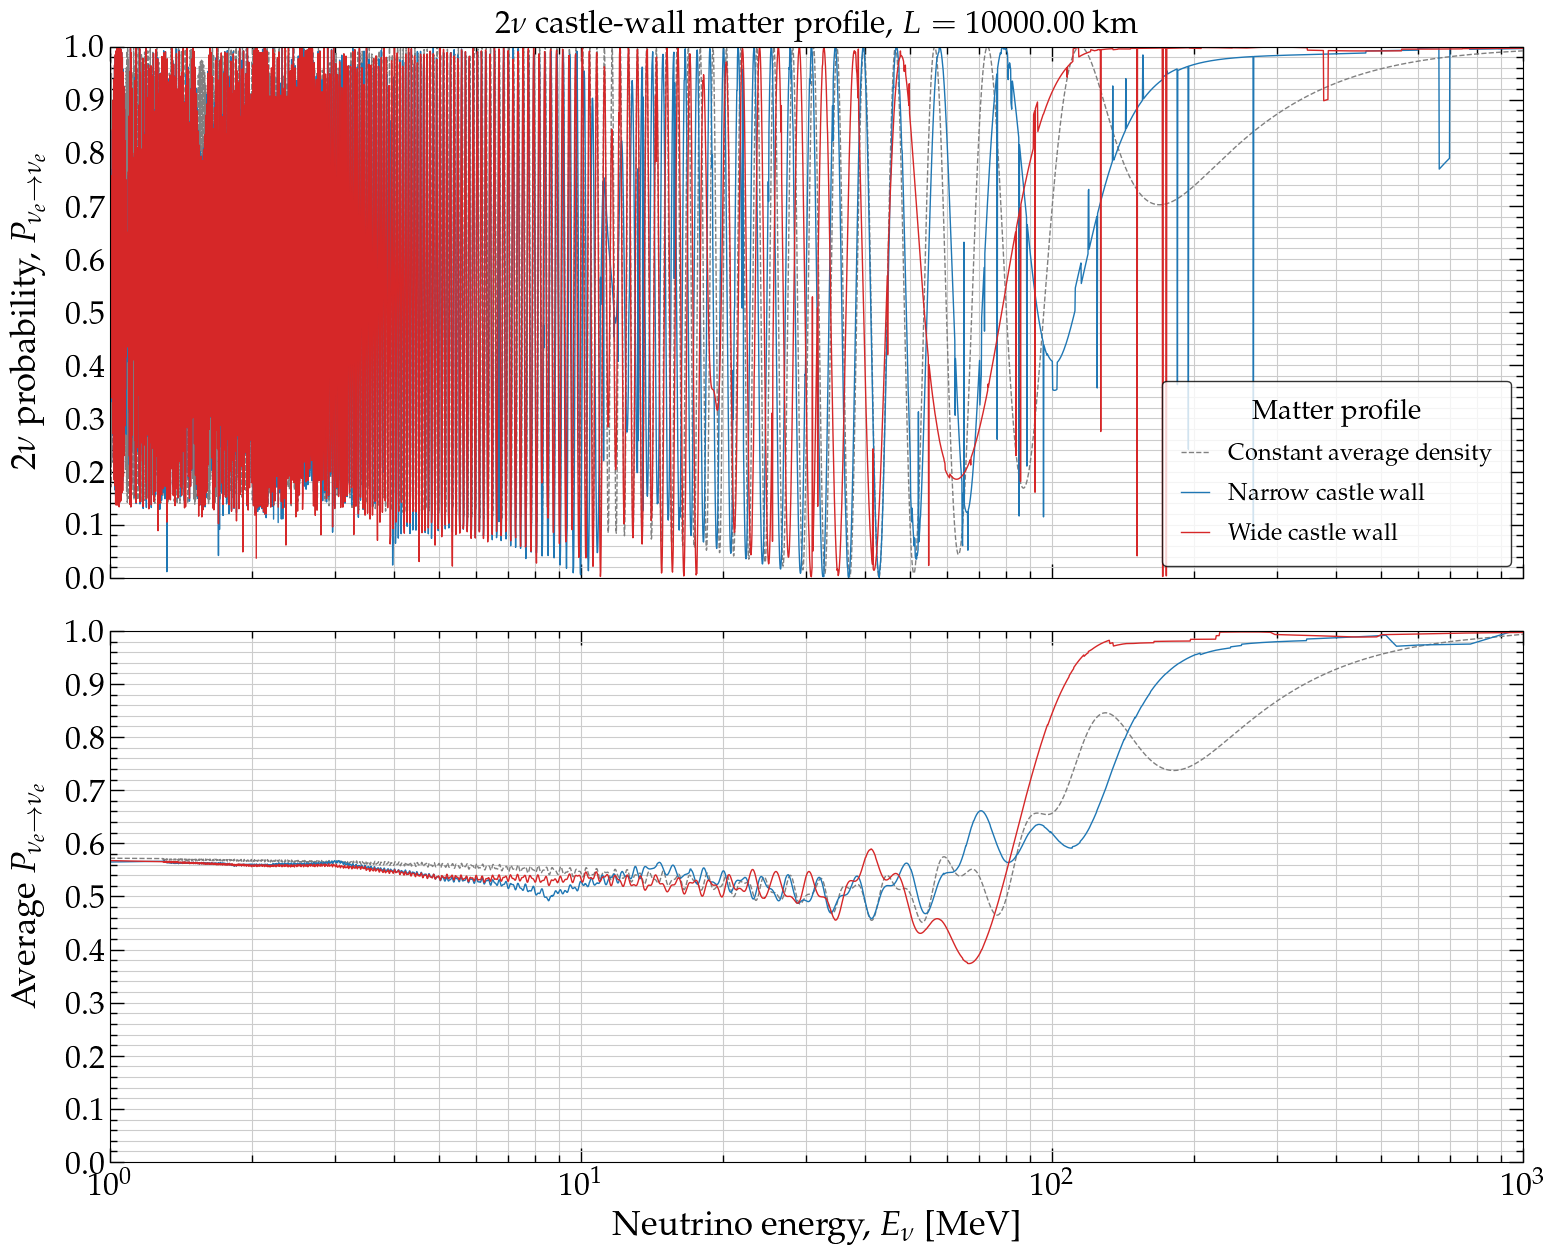

In [25]:
smooth = lambda y: sp.signal.savgol_filter(y, window_length=301, polyorder=1)
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_matt_const_density, label=r'Constant average density', color='0.5', ls='--'),
      dict(y=prob_matt_castle_wall_narrow, label=r'Narrow castle wall', color='C0'),
      dict(y=prob_matt_castle_wall_wide, label=r'Wide castle wall', color='C3')],
     [dict(y=smooth(prob_matt_const_density), color='0.5', ls='--'),
      dict(y=smooth(prob_matt_castle_wall_narrow), color='C0'),
      dict(y=smooth(prob_matt_castle_wall_wide), color='C3')]],
    xlim=(energy_min, energy_max), xscale='log',
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$2\nu$~castle-wall matter profile, $L = $~{:.2f}~km'.format(baseline),
    legend_title=r'Matter profile', legend_loc='lower right', legend_on_panel=0)

# 5. Probabilities 2$\nu$: in matter with noisy density profile

## 5.1 General definitions

In [26]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [27]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale = 100.0 # [km]

# Build the noise
np.random.seed(20)
# High-amplitude, more marked noise
npts_noise = 50 # Use more points to make it more finely noised
x_high = np.linspace(0, 1, npts_noise)
noise_sample_high = np.random.normal(loc=1.0, scale=0.3, size=npts_noise) # Increase scale to increase the width of the noise bumps
noise_mask_high_interp = sp.interpolate.make_interp_spline(x_high, noise_sample_high, k=1)
# Low-amplitude, choppier noise
npts_noise = 300 # Use more points to make it more finely noised
x_low = np.linspace(0, 1, npts_noise)
noise_sample_low = np.random.normal(loc=1.0, scale=0.08, size=npts_noise) # Increase scale to increase the width of the noise bumps
noise_mask_low_interp = sp.interpolate.make_interp_spline(x_low, noise_sample_low, k=1)

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper.
# [l] = km
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_center) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, constant density, with noise around central value
# --------------------------------------------------------------
def num_density_e_const_noisy_func(l, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
    if noise_model == 'high-amplitude':
        return num_density_e_const*noise_mask_high_interp(l_scaled)
    elif noise_model == 'low-amplitude':
        return num_density_e_const*noise_mask_low_interp(l_scaled)
def VCC_func_const_density_noisy(l, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    return matter.VCC_func(l, lambda r: num_density_e_const_noisy_func(r, num_density_e_const, l_ini, l_fin, 
                                                                       noise_model=noise_model)) # [eV]
def H_func_const_density_noisy(l, energy, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_noisy(l, num_density_e_const, 
                                                                                                             l_ini, l_fin,
                                                                                                             noise_model=noise_model))
# # --------------------------------------------------------------
# # In matter, exponentially falling density
# # --------------------------------------------------------------
# # [l] = km
# def num_density_e_exp_func(l, num_density_e_center, l_scale):
#     return num_density_e_center*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale) # [eV^3]
# def VCC_func_exp_density(l, num_density_e_center, l_scale):
#     return matter.VCC_func(l, lambda r: num_density_e_exp_func(r, num_density_e_center, l_scale)) # [eV]
# def H_func_exp_density(l, energy):
#     return (1/energy)*H_vac_energy_indep-hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density(l, num_density_e_center, l_scale))

# # --------------------------------------------------------------
# # In matter, exponentially falling density, noisy
# # --------------------------------------------------------------
# # [l] = km
# def num_density_e_exp_noisy_func(l, num_density_e_center, l_scale, l_ini, l_fin):
#     l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
#     return num_density_e_exp_func(l, num_density_e_center, l_scale)*noise_mask_interp(l_scaled)
# def VCC_func_exp_density_noisy(l, num_density_e_center, l_scale, l_ini, l_fin):
#     return matter.VCC_func(l, lambda r: num_density_e_exp_noisy_func(r, num_density_e_center, l_scale, l_ini, l_fin)) # [eV]
# def H_func_exp_density_noisy(l, energy, num_density_e_center, l_scale, l_ini, l_fin):
#     return (1/energy)*H_vac_energy_indep \
#         - hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density_noisy(l, num_density_e_center, l_scale, l_ini, l_fin))

## 5.2 Probabilities vs. distance

### Generate probabilities

In [28]:
# Baselines
l_ini, l_fin = 1.e2, 1.e5 # [km]
l_npts = 6000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 50.*gd.UNIT_MEV # [eV] #10

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, constant density, high-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_high_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, energy, 
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='high-amplitude'), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_low_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, energy, 
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='low-amplitude'), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

# # --------------------------------------------------------------
# # In matter, exponentially falling density
# # --------------------------------------------------------------
# prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, energy), 
#                                                    0, l*gd.CONV_KM_TO_INV_EV, 
#                                                    n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

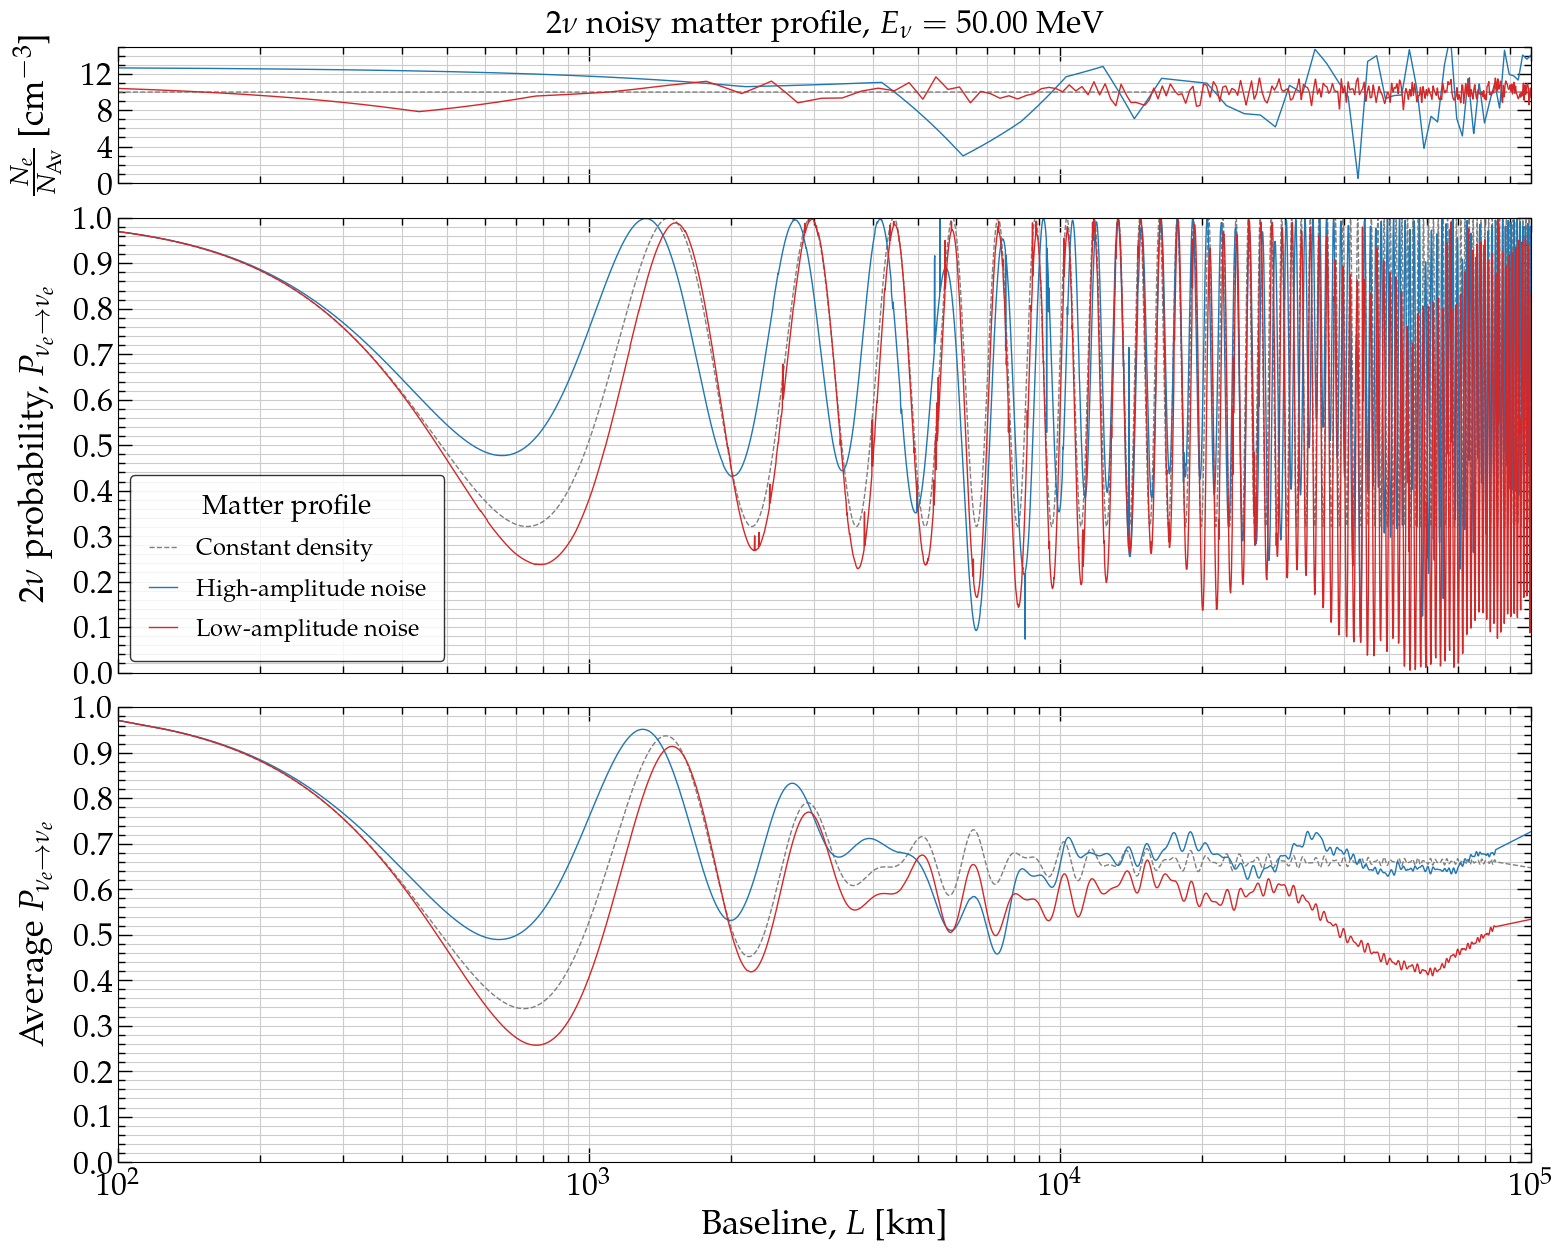

In [29]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
smooth = lambda y: sp.signal.savgol_filter(y, window_length=301, polyorder=1)
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center/norm for l in distances], color='0.5', ls='--'),
     dict(y=[num_density_e_const_noisy_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center,
                                            l_ini, l_fin,
                                            noise_model='high-amplitude')/norm
             for l in distances], color='C0'),
     dict(y=[num_density_e_const_noisy_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center,
                                            l_ini, l_fin,
                                            noise_model='low-amplitude')/norm
             for l in distances], color='C3')],
    [[dict(y=prob_matt_const_density, label=r'Constant density', color='0.5', ls='--'),
      dict(y=prob_matt_const_density_noisy_high_amplitude, label=r'High-amplitude noise', color='C0'),
      dict(y=prob_matt_const_density_noisy_low_amplitude, label=r'Low-amplitude noise', color='C3')],
     [dict(y=smooth(prob_matt_const_density), color='0.5', ls='--'),
      dict(y=smooth(prob_matt_const_density_noisy_high_amplitude), color='C0'),
      dict(y=smooth(prob_matt_const_density_noisy_low_amplitude), color='C3')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 15),
    profile_ymajor=4, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]', ylabel_labelpad=15,
    title=r'$2\nu$~noisy matter profile, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Matter profile', legend_loc='lower left', legend_on_panel=0)

## 5.3 Probabilities vs. energy

### Generate probabilities

In [30]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 6000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e5 # [km]

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, constant density, high-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_high_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, enu*gd.UNIT_MEV,
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='high-amplitude'), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_low_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, enu*gd.UNIT_MEV,
                                                                                                            num_density_e_center,
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='low-amplitude'), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

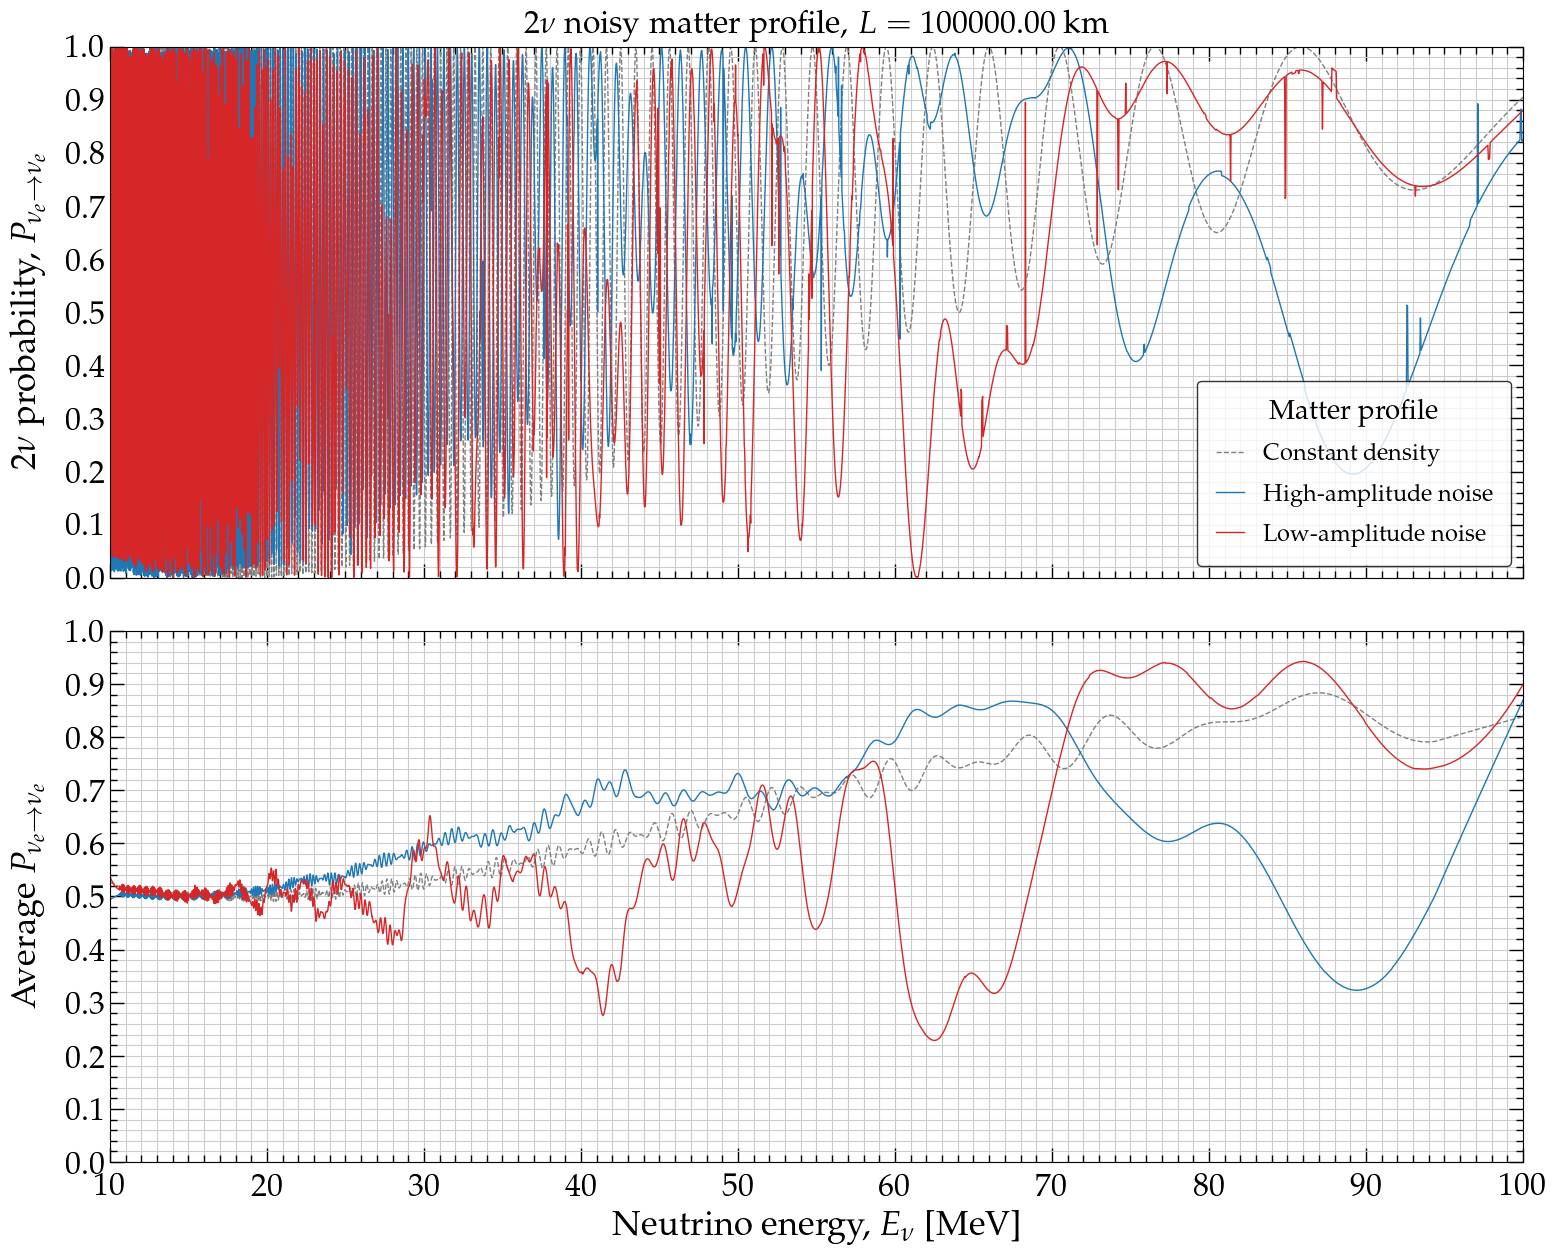

In [31]:
smooth = lambda y, po=1: sp.signal.savgol_filter(y, window_length=301, polyorder=po)
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_matt_const_density, label=r'Constant density', color='0.5', ls='--'),
      dict(y=prob_matt_const_density_noisy_high_amplitude, label=r'High-amplitude noise', color='C0'),
      dict(y=prob_matt_const_density_noisy_low_amplitude, label=r'Low-amplitude noise', color='C3')],
     [dict(y=smooth(prob_matt_const_density), color='0.5', ls='--'),
      dict(y=smooth(prob_matt_const_density_noisy_high_amplitude), color='C0'),
      dict(y=smooth(prob_matt_const_density_noisy_low_amplitude, 2), color='C3')]],
    xlim=(energy_min, energy_max), xscale='linear', xmajor=10, xminor=1,
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$2\nu$~noisy matter profile, $L = $~{:.2f}~km'.format(baseline),
    legend_title=r'Matter profile', legend_loc='lower right', legend_on_panel=0)

# 6. Probabilities 2$\nu$: in the Earth

## 6.1 General definitions

In [32]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [33]:
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # [eV^{-3}]

def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# [l] = km
def H_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_prem(r))

# Test values of the zenith angle, cos(theta_z), to plot, with theta_z = 0 normal to the surface of the Earth, at the position of the
# detector.  All of the direction are upgoing.
costhz_val = [-0.1, -0.5, -1.0]

# Maximum baselines inside the Earth
l_max_val = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_val] # [km]

## 6.2 Probabilities vs. distance

### Generate probabilities

In [34]:
# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]

nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 20.*gd.UNIT_MEV # [eV] #10

l_min = 1.e2 # [km]

# Generate probabilities for the different directions
distances_val, prob_val = [], []
l_npts = 3000
for i in range(len(costhz_val)):
    print("costhz = "+str(costhz_val[i]))
    distances = np.logspace(np.log10(l_min), np.log10(l_max_val[i]), l_npts) # [km]
    distances_val.append(distances)
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_val[i], l, energy), 0, l*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for l in distances]) 
    prob_val.append(prob)

costhz = -0.1


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


costhz = -0.5


costhz = -1.0


### Plot probabilities

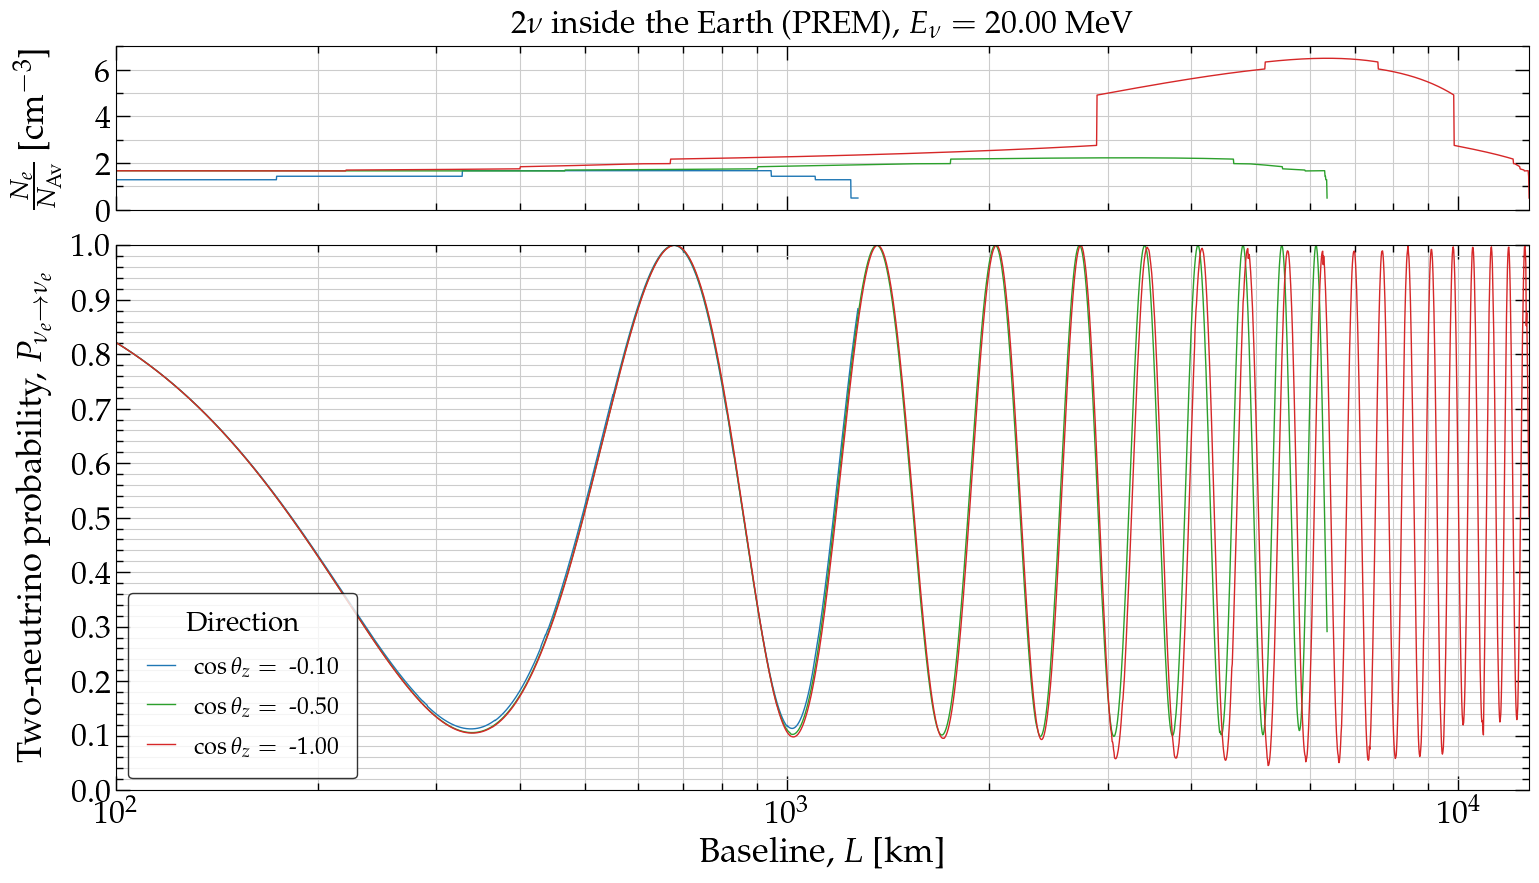

In [35]:
lc = ['C0', 'C2', 'C3']
ls = ['-', '-', '-']
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
profiles, panel = [], []
for i in range(len(costhz_val)):
    n_e = np.array([num_density_e_func_prem(
                        earth.earth_radial_distance_from_depth(costhz_val[i], l))
                    for l in distances_val[i]])/norm
    profiles.append(dict(x=distances_val[i], y=n_e, color=lc[i], ls=ls[i]))
    panel.append(dict(x=distances_val[i], y=prob_val[i], color=lc[i], ls=ls[i],
                      label=r'$\cos \theta_z = $~~{:.2f}'.format(costhz_val[i])))

fig, ax = plotting.plot_probability_with_profile(
    distances_val[0], profiles, [panel],
    xlim=(l_min, max(l_max_val)), profile_ylim=(0, 7),
    profile_ymajor=2, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$2\nu$~inside the Earth (PREM), $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Direction', legend_loc='lower left')

## 6.3 Probabilities vs. energy

### Generate probabilities

In [36]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 3000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Generate probabilities for the different directions
prob_val = []
for i in range(len(costhz_val)):
    print("costhz = "+str(costhz_val[i]))
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_val[i], l, enu*gd.UNIT_MEV), 
                                      0, l_max_val[i]*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_val.append(prob)

costhz = -0.1


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


costhz = -0.5


costhz = -1.0


### Plot probabilities

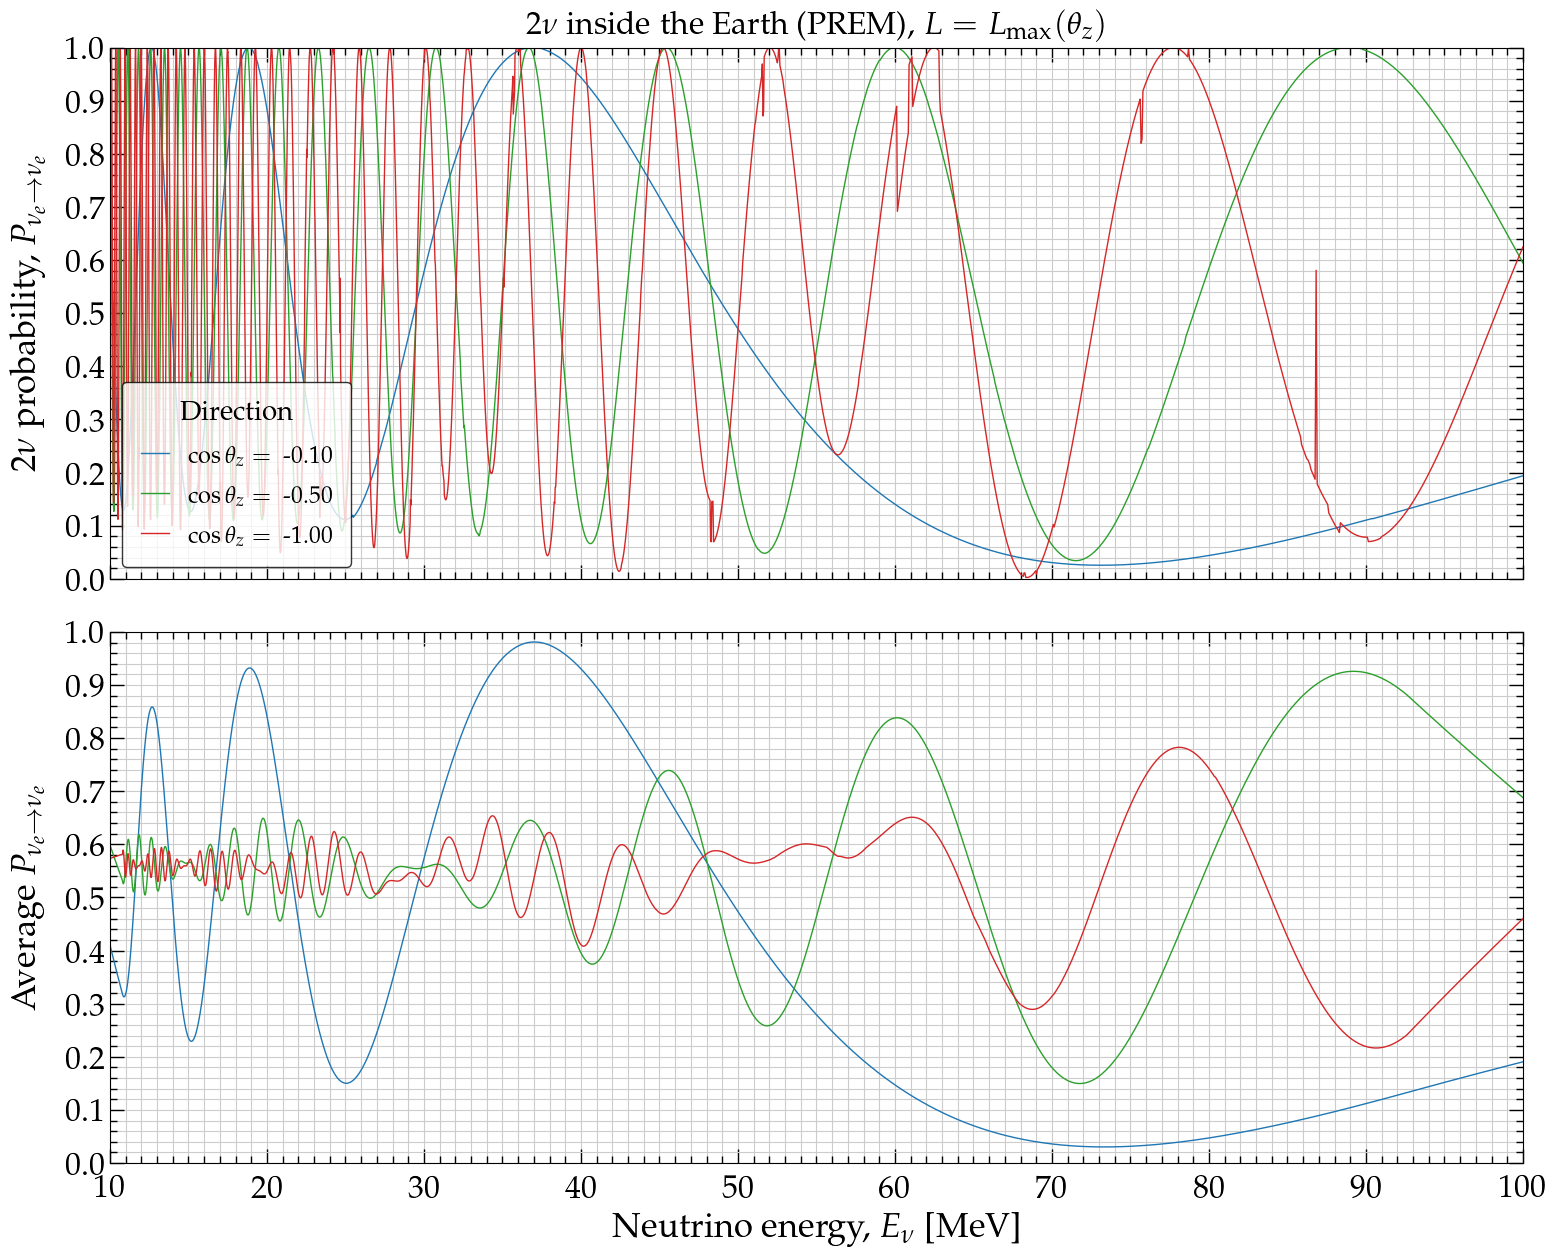

In [37]:
smooth = lambda y: sp.signal.savgol_filter(y, window_length=201, polyorder=1)
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_val[i], color=lc[i], ls=ls[i],
           label=r'$\cos \theta_z = $~~{:.2f}'.format(costhz_val[i]))
      for i in range(len(costhz_val))],
     [dict(y=smooth(prob_val[i]), color=lc[i], ls=ls[i])
      for i in range(len(costhz_val))]],
    xlim=(energy_min, energy_max), xscale='linear', xmajor=10, xminor=1,
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$2\nu$~inside the Earth (PREM), $L = L_{\rm max}(\theta_z)$',
    legend_title=r'Direction', legend_loc='lower left', legend_on_panel=0)

# 7. Probabilities 2$\nu$: in the Sun

## 7.1 General definitions

In [38]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [39]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center_sun = 245*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale_sun = gd.SUN_RADIUS/10.54 # [km]

# Potential assuming constant density: the matter density is constant, so this is merely a wrapper.
# [l] = km
def num_density_e_sun_const_func(l):
    return num_density_e_center_sun # [eV^3]
def VCC_func_const_density_sun(l):
    return matter.VCC_func(l, num_density_e_sun_const_func) # [eV]

# Potential assuming exponentially decreasing density
# [l] = km
def num_density_e_sun_exp_func(l):
    return num_density_e_center_sun*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale_sun) # [eV^3]
def VCC_func_exp_sun(l):
    return matter.VCC_func(l, num_density_e_sun_exp_func) # [eV]

## 7.2 Probabilities vs. distance

### Generate probabilities

In [40]:
# Baselines
l_ini, l_fin = 1.e-3, 1.0 # l/SUN_RADIUS
l_npts = 1000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # l/SUN_RADIUS

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 5.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_func_const_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      + hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_sun(l))
prob_matt_const_density = np.array([oscprob.osc_prob(H_func_const_density, 
                                                     0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
H_func_exp_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      + hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_sun(l))
# H_func_exp_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      # + hamiltonians.hamiltonian_2nu_matter(-VCC_func_exp_sun(l))
prob_matt_exp_density = np.array([oscprob.osc_prob(H_func_exp_density, 
                                                   0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for l in distances])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
# Using Magnus expansion
H_func = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2)
prob_vac = np.array([oscprob.osc_prob(H_func,
                                      0.0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])
# # Using standard formula
# prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

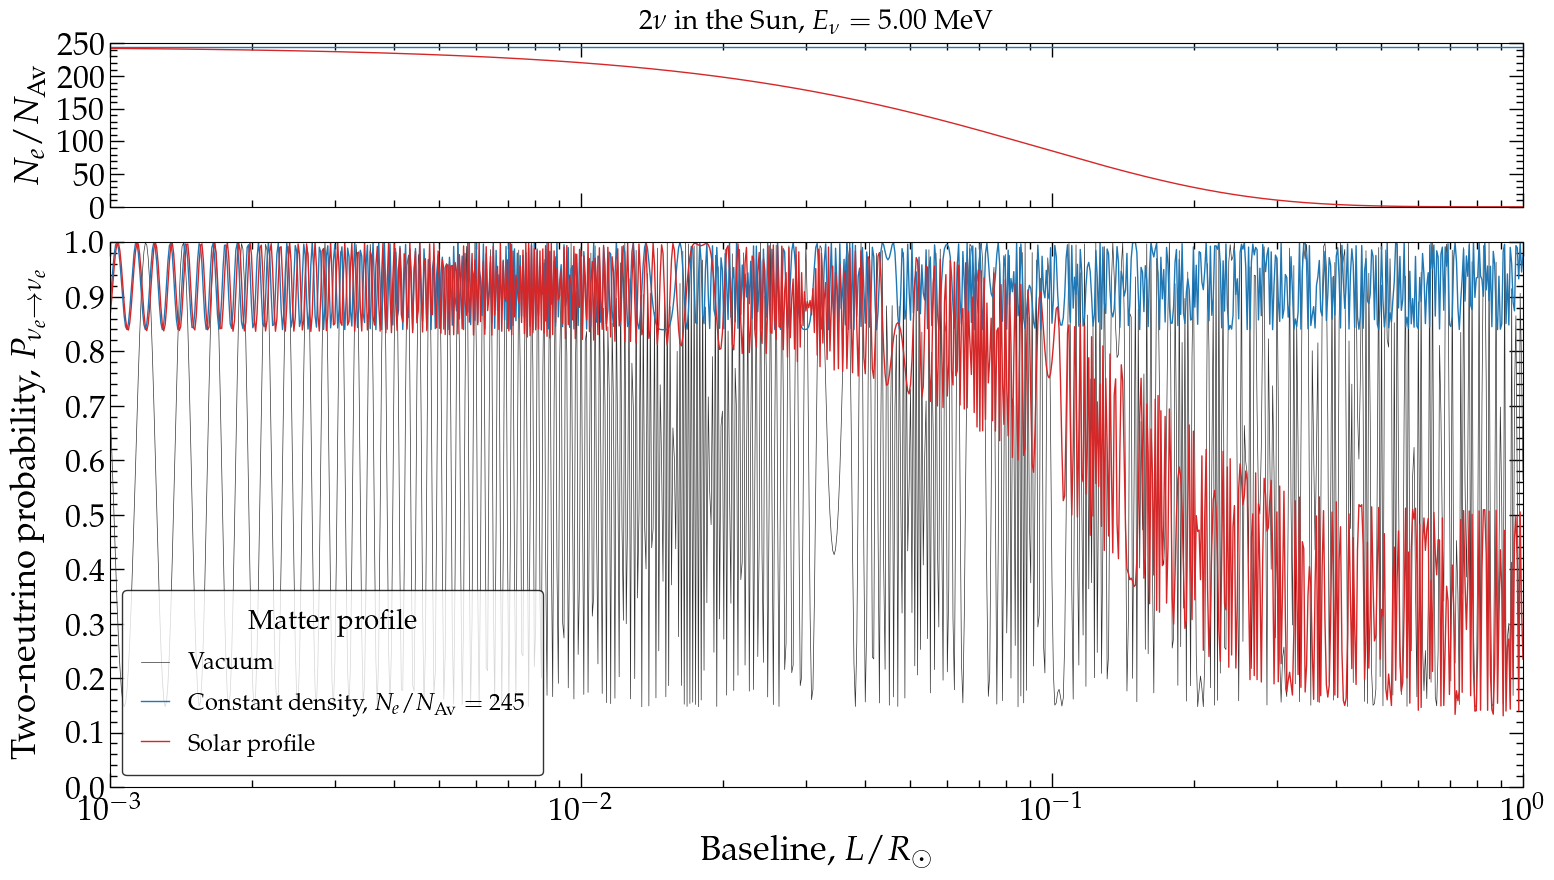

In [41]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center_sun/norm for l in distances], color='C0'),
     dict(y=[num_density_e_center_sun/norm*np.exp(-l*gd.SUN_RADIUS/l_scale_sun)
             for l in distances], color='C3')],
    [[dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
      dict(y=prob_matt_const_density, color='C0',
           label=r'Constant density, $N_e/N_{\rm Av} =~$'
                 + '{:.0f}'.format(num_density_e_center_sun/norm)),
      dict(y=prob_matt_exp_density, label=r'Solar profile', color='C3')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 250),
    profile_ymajor=50, profile_yminor=10, profile_height=0.3,
    profile_ylabel=r'$N_e/N_{\rm Av}$',
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L/R_\odot$', ylabel_labelpad=7,
    title=r'$2\nu$~in the Sun, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    title_fontsize=20, legend_title=r'Matter profile', legend_loc='lower left',
    grid=False)

## 7.3 Probabilities vs. energy

### Generate probabilities

In [42]:
# Energies
energy_min, energy_max = 1.e-1, 1.e2 # [MeV]
energy_npts = 1000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = gd.SUN_RADIUS # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_matt = hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_sun(0.0)) # Matter Hamiltonian [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_sun(l)) 
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=2, n_jobs=10)[nu_i][nu_f] \
                                                   # n_slabs=200, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

/tmp/ipykernel_331538/2392756941.py:19: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), so convergence could not be verified by successive refinement; the returned probabilities may be inaccurate. Try increasing max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. Shown once per session.
  prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1110: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,
/tmp/ipykernel_331538/2392756941.py:28: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), so convergence could not be verified by successive refinement; the returned probabilities may be inaccurate. Try increasing max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. Shown once per session.
  prob_matt_exp_density = np.array([osc

/tmp/ipykernel_331538/2392756941.py:37: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), so convergence could not be verified by successive refinement; the returned probabilities may be inaccurate. Try increasing max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. Shown once per session.
  prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep,


### Plot probabilities

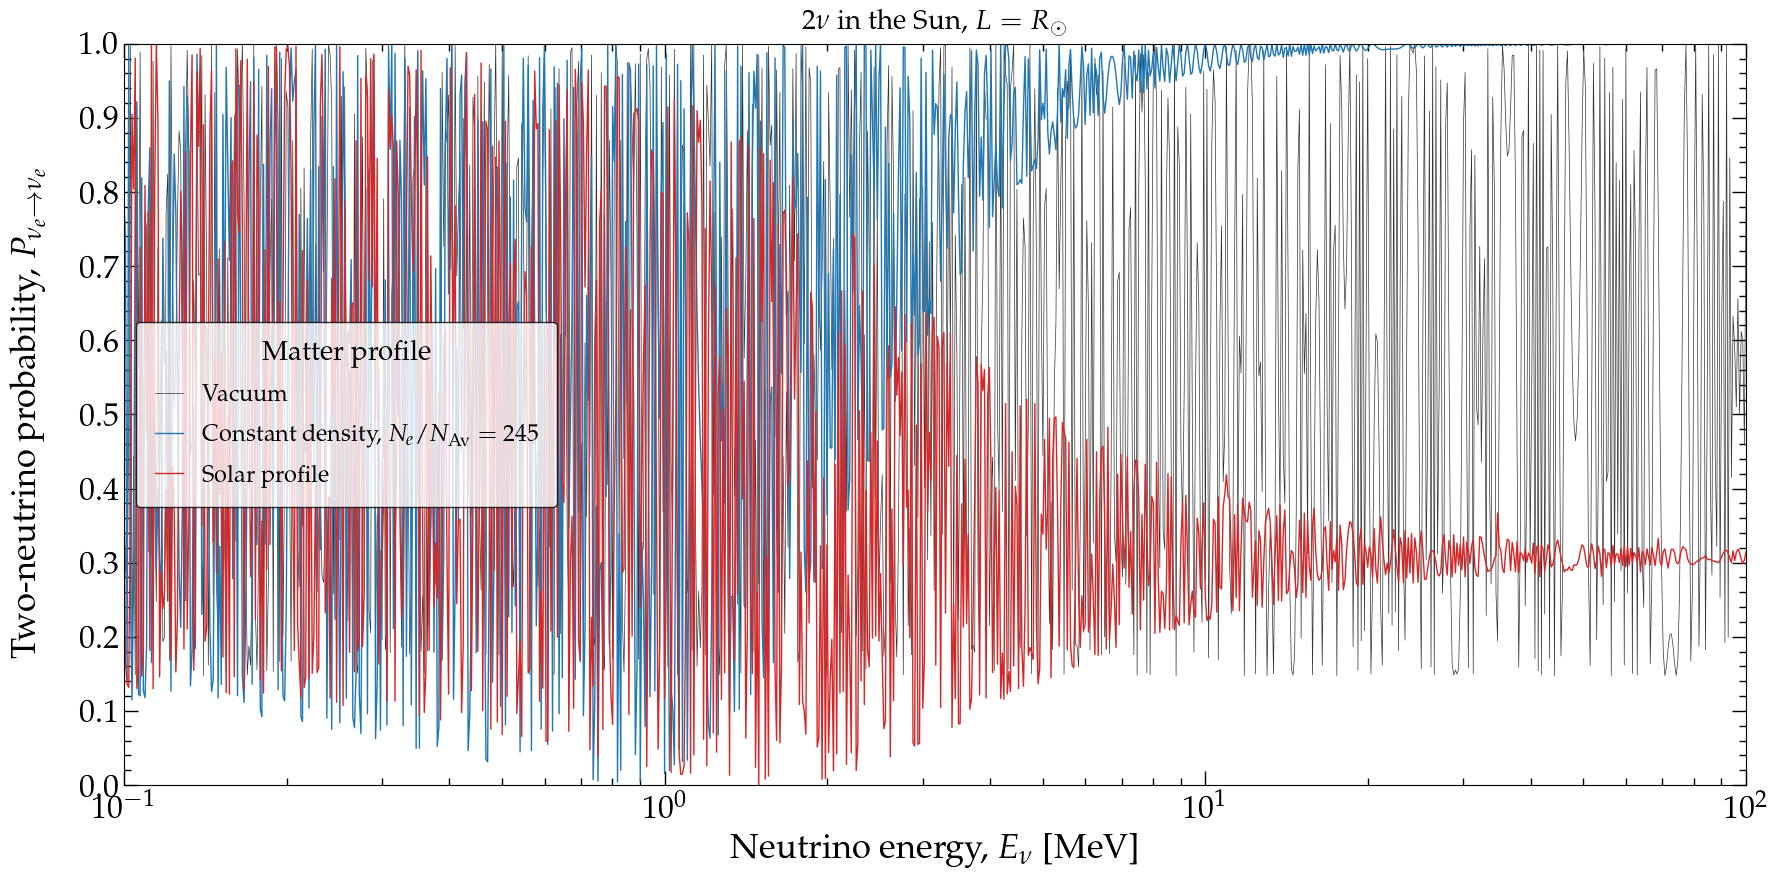

In [43]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
     dict(y=prob_matt_const_density, color='C0',
          label=r'Constant density, $N_e/N_{\rm Av} =~$'
                + '{:.0f}'.format(num_density_e_center_sun/norm)),
     dict(y=prob_matt_exp_density, label=r'Solar profile', color='C3')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2, energy_unit='MeV',
    xlim=(energy_min, energy_max),
    legend_title=r'Matter profile', legend_loc='center left',
    title=r'$2\nu$~in the Sun, $L = R_\odot$')